# 09. 정규화, 규제, 일반화


1. **정규화(Normalization)**: 입력 데이터나 신경망 중간값의 분포와 크기를 조정해 학습을 안정시킨다.
2. **규제(Regularization)**: 모델이 학습 데이터를 지나치게 외우지 못하게 제한한다.
3. **일반화(Generalization)**: 학습에 사용하지 않은 새로운 데이터에서도 좋은 예측을 만드는 능력이다.

딥러닝 모델의 최종 목표는 학습 데이터를 외우는 것이 아니라 새로운 데이터에서도 안정적으로 예측하는 것이다.
정규화는 그 목표로 가는 **학습 과정을 안정시키는 방법**이고, 규제는 **과적합을 줄이는 방법**이다.


## 1. 정규화, 규제와 일반화

### 정규화란 무엇인가

정규화는 **서로 다른 범위와 분포를 가진 값을 모델이 학습하기 쉬운 범위로 조정하는 과정**이다.

예를 들어 입력 특성 두 개의 값이 다음과 같다고 생각한다.

```text
특성 1: 0.2, 0.5, 0.8
특성 2: 1,000, 2,000, 3,000
```

초기 가중치의 크기가 비슷하면 두 번째 특성의 큰 숫자가 선형 계산과 기울기에 훨씬 크게 반영될 수 있다. 모델이 이를 보정하는 가중치를 학습할 수는 있지만, 그 과정에서 손실 지형이 한쪽은 가파르고 다른 쪽은 완만해져 optimizer가 최솟값을 향해 안정적으로 이동하기 어려워질 수 있다.

가장 익숙한 방법은 각 값에서 평균을 빼고 표준편차로 나누는 **표준화(Standardization)** 이다.

$$
x'=\frac{x-\mu}{\sigma}
$$

- $x$: 변환할 원래 값
- $\mu$: 정규화 대상으로 묶은 값들의 평균
- $\sigma$: 해당 값들의 표준편차
- $x'$: 평균 0, 분산 1에 가까워진 값

정규화는 모든 값을 0으로 만들거나 정보를 삭제하는 과정이 아니다. 값들의 상대적인 크기와 패턴은 유지하면서 중심과 크기를 조정한다. 또한 모든 정규화가 반드시 `[0, 1]` 범위를 만드는 것은 아니다.

> `Normalization`은 값의 범위를 조정하는 방법 전체를 가리키는 넓은 표현이다. 일부 머신러닝 자료에서는 `[0, 1]`로 바꾸는 Min-Max Scaling만 정규화라고 부르기도 한다. 이 노트북의 BatchNorm과 LayerNorm은 평균과 분산을 사용하는 표준화에 가까운 방식이다.


### 정규화를 하는 이유

- **특성 크기의 차이를 완화한다.** 특정 특성의 큰 숫자만 선형 계산과 기울기를 과도하게 지배하는 현상을 줄인다.
- **기울기 크기를 비교적 안정적으로 유지한다.** 계층마다 값의 범위가 급격하게 달라지는 문제를 완화한다.
- **optimizer가 이동하기 쉬운 손실 지형을 만든다.** 한쪽으로 길게 늘어난 손실 지형에서 지그재그로 이동하는 현상을 줄일 수 있다.
- **활성화 함수의 포화 구간 진입을 줄인다.** Sigmoid나 Tanh에 지나치게 큰 절댓값이 들어가 기울기가 작아지는 문제를 완화할 수 있다.
- **학습률 선택을 비교적 수월하게 한다.** 값의 범위가 안정되면 너무 작은 학습률만 사용해야 하는 상황이 줄어들 수 있다.

정규화가 항상 정확도를 높이거나 과적합을 막아 주는 것은 아니다. 주된 목적은 **학습 속도와 수치적 안정성 개선**이다.

### 어디에서 정규화하는가

- **입력 데이터 정규화**: 모델에 넣기 전에 각 입력 특성의 범위를 맞춘다. 뒤의 실습에서는 `StandardScaler`를 사용한다.
- **Batch Normalization**: 신경망 중간 활성화를 mini-batch의 같은 특성끼리 정규화한다.
- **Layer Normalization**: 각 샘플이 가진 특성들을 샘플 내부에서 정규화한다.

입력 데이터의 평균과 표준편차는 반드시 **학습 데이터에서만 계산**해야 한다. 검증·테스트 데이터의 통계를 미리 사용하면 평가 대상의 정보가 학습 과정에 들어가는 데이터 누수가 발생한다.

### 정규화와 규제는 목적이 다르다

- **정규화**는 값의 분포를 조정해 최적화를 안정시키는 방법이다. 대표적으로 입력 표준화, BatchNorm과 LayerNorm이 있다.
- **규제**는 모델의 복잡도나 학습 방식을 제한해 과적합을 줄이는 방법이다. 대표적으로 Dropout, L1/L2, weight decay와 데이터 증강이 있다.
- **학습 제어**는 검증 지표에 따라 학습률이나 학습 종료 시점을 조절한다. 대표적으로 scheduler와 early stopping이 있다.

BatchNorm은 mini-batch 통계에 포함된 잡음 때문에 부수적인 규제 효과가 나타날 수 있지만, 주된 목적은 중간 활성화의 분포를 조정해 학습을 안정시키는 것이다.

### 과적합과 일반화

- **과소적합**: 모델이 학습 데이터의 패턴도 충분히 학습하지 못한 상태이다.
- **적절한 학습**: 학습과 검증 성능이 함께 좋아지는 상태이다.
- **과적합**: 학습 데이터에는 잘 맞지만 검증 데이터 성능은 정체되거나 나빠지는 상태이다.
- **일반화**: 학습에 사용하지 않은 데이터에서도 좋은 성능을 내는 능력이다.

학습 손실만으로는 일반화 성능을 판단할 수 없다. 반드시 train과 validation 지표를 함께 확인해야 한다.


### 실습 환경 준비

정규화·규제 실습에 필요한 PyTorch와 scikit-learn 모듈을 불러오고 난수 시드를 고정한다.

In [1]:
import copy


import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)


## 2. Batch Normalization과 Layer Normalization

### 정규화가 필요한 이유

신경망의 중간값은 학습 중에 계속 변한다. 어떤 특성은 값이 매우 크고 다른 특성은 매우 작으면 계층마다 받아들이는 값의 범위가 달라져 학습이 불안정해질 수 있다.

정규화는 값을 대략 **평균 0, 분산 1**인 범위로 맞춰 다음 계층이 비교적 일정한 크기의 입력을 받게 한다. 입력과 출력의 shape은 바뀌지 않고 값의 분포만 조정된다.

BatchNorm과 LayerNorm의 가장 중요한 차이는 **평균과 분산을 계산할 때 어떤 값들을 한 묶음으로 보는가**이다.

### Batch Normalization: 같은 열끼리 계산

다음과 같이 행이 샘플이고 열이 특성인 Tensor가 있다고 생각한다.

```text
          특성 1   특성 2   특성 3
샘플 1       1       10      100
샘플 2       2       20      110
샘플 3       3       30      120
샘플 4       4       40      130
             ↑       ↑       ↑
          열별로 평균과 분산 계산
```

BatchNorm은 현재 mini-batch에서 **같은 특성에 해당하는 열끼리** 평균과 분산을 계산한다.
특성 1은 `[1, 2, 3, 4]`, 특성 2는 `[10, 20, 30, 40]`, 특성 3은 `[100, 110, 120, 130]`을 각각 별도로 정규화한다.

```python
batch_norm = nn.BatchNorm1d(3)
```

`3`은 입력에 특성이 3개 있다는 뜻이다. 정규화 전후의 Tensor shape은 모두 `(4, 3)`이다.

학습 모드에서는 현재 batch의 평균·분산을 사용하면서 이동 통계인 `running_mean`과 `running_var`를 갱신한다.
평가 모드에서는 새로운 데이터의 batch 통계 대신 학습 중 누적한 이동 통계를 사용한다.
따라서 batch가 지나치게 작으면 통계가 불안정할 수 있다.

### Layer Normalization: 같은 행 안에서 계산

LayerNorm은 batch의 다른 샘플과 비교하지 않고 **샘플 하나가 가진 특성들**, 즉 같은 행 안에서 평균과 분산을 계산한다.

```text
샘플 1  [ 1,  2,  3,  4]  → 이 네 값의 평균과 분산 사용
샘플 2  [10, 20, 30, 40]  → 이 네 값의 평균과 분산 사용
샘플 3  [-3, -1, 1,  3]  → 이 네 값의 평균과 분산 사용
```

```python
layer_norm = nn.LayerNorm(4)
```

`4`는 각 샘플에서 마지막 차원의 특성 4개를 정규화한다는 뜻이다. 다른 샘플의 값이나 batch 크기에 의존하지 않으며, 학습과 평가에서 같은 방식으로 현재 샘플의 통계를 사용한다. 이러한 특징 때문에 Transformer와 시퀀스 모델에서 널리 사용한다.

### 수식은 두 방식이 같다

$$
\hat{x}=\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}},
\qquad y=\gamma\hat{x}+\beta
$$

- $\mu$: 선택한 묶음의 평균
- $\sigma^2$: 선택한 묶음의 분산
- $\epsilon$: 0으로 나누는 문제를 막는 매우 작은 값
- $\gamma$: 정규화된 값의 크기를 다시 조절하는 학습 파라미터
- $\beta$: 정규화된 값의 위치를 다시 이동하는 학습 파라미터

결국 BatchNorm과 LayerNorm은 같은 표준화 공식을 사용하지만, **BatchNorm은 열 방향**, **LayerNorm은 행 방향**으로 통계를 계산한다고 이해하면 된다.

### BatchNorm의 특성별 정규화 확인

mini-batch의 같은 열끼리 평균과 분산을 계산하고 gamma와 beta의 shape을 확인한다.

In [2]:
batch = torch.tensor([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 110.0],
    [3.0, 30.0, 120.0],
    [4.0, 40.0, 130.0],
])

# nn.BatchNorm1d(3): 입력 데이터의 feature수(3)
# - 각 열의 batch 평균과 분산으로 정규화 수행
batch_norm = nn.BatchNorm1d(3)

batch_norm.train() # 학습 모드

normalized = batch_norm(batch) # 정규화 수행, 이때 shape 그대로 유지


print("입력의 특성별 평균:", batch.mean(dim=0))
print("출력의 특성별 평균:", normalized.mean(dim=0))


print("출력의 특성별 분산:", normalized.var(dim=0, unbiased=False))

# 정규화 후 학습 가능한 gamma로 크기를 조정하고 beta로 위치를 수정한다.
# == 정규화된 데이터에 맞춰 선형 방정식을 다시 계산
# gamma == W(가중치)
# beta == bias(편향)
print("gamma shape:", batch_norm.weight.shape)
print("beta shape:", batch_norm.bias.shape)


입력의 특성별 평균: tensor([  2.5000,  25.0000, 115.0000])
출력의 특성별 평균: tensor([ 8.9407e-08,  1.4901e-07, -4.7684e-07], grad_fn=<MeanBackward1>)
출력의 특성별 분산: tensor([1.0000, 1.0000, 1.0000], grad_fn=<VarBackward0>)
gamma shape: torch.Size([3])
beta shape: torch.Size([3])


### LayerNorm과 수동 계산 비교

LayerNorm은 **다른 샘플과 비교하지 않고, 샘플 하나의 특성들끼리 정규화**한다.

첫 번째 샘플 `[1, 2, 3, 4]`를 예로 들면 다음 순서로 계산한다.

1. 평균을 계산한다: $(1+2+3+4)/4=2.5$
2. 각 값에서 평균을 뺀다: `[-1.5, -0.5, 0.5, 1.5]`
3. 분산은 네 편차 제곱의 평균인 `1.25`이다.
4. 표준편차는 $\sqrt{1.25}$인 약 `1.118`이다.
5. 편차를 표준편차로 나누면 약 `[-1.342, -0.447, 0.447, 1.342]`가 된다.

```text
[1, 2, 3, 4]
      ↓ 행 내부 평균과 분산 계산
[-1.342, -0.447, 0.447, 1.342]
```

두 번째와 세 번째 샘플도 각각 자기 행 안에서 같은 계산을 수행한다. 코드의 `dim=1`은 **열을 가로질러 각 행별로 계산한다**는 뜻이다.



In [3]:
features = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [10.0, 20.0, 30.0, 40.0],
    [-3.0, -1.0, 1.0, 3.0],
])
print("입력 Tensor:")
print(features)

# elementwise_affine=False:
# 학습 가능한 gamma, beta를 제외하고 표준화 계산만 확인
layer_norm = nn.LayerNorm(4, elementwise_affine=False)
first_sample = features[0]

first_mean = first_sample.mean()
first_variance = first_sample.var(unbiased=False)
first_std = torch.sqrt(first_variance + layer_norm.eps)
first_manual_output = (first_sample - first_mean) / first_std

print("\n첫 번째 샘플:", first_sample)
print("첫 번째 샘플 평균:", first_mean.item())
print("첫 번째 샘플 분산:", first_variance.item())
print("첫 번째 샘플 표준편차:", first_std.item())
print("첫 번째 샘플 수동 정규화:", first_manual_output)


입력 Tensor:
tensor([[ 1.,  2.,  3.,  4.],
        [10., 20., 30., 40.],
        [-3., -1.,  1.,  3.]])

첫 번째 샘플: tensor([1., 2., 3., 4.])
첫 번째 샘플 평균: 2.5
첫 번째 샘플 분산: 1.25
첫 번째 샘플 표준편차: 1.1180384159088135
첫 번째 샘플 수동 정규화: tensor([-1.3416, -0.4472,  0.4472,  1.3416])


In [4]:
layer_output = layer_norm(features)
print("\nPyTorch LayerNorm 결과:")
print(layer_output)


row_means = features.mean(dim=1, keepdim=True)
row_variances = features.var(dim=1, keepdim=True, unbiased=False)


manual_output = (features - row_means) / torch.sqrt(row_variances + layer_norm.eps)

print("\n행별 평균:")
print(row_means)
print("행별 분산:")
print(row_variances)
print("전체 샘플 수동 정규화:")
print(manual_output)


max_difference = (layer_output - manual_output).abs().max().item()
print("수동 계산과 최대 차이:", max_difference)


print("샘플별 출력 평균:", layer_output.mean(dim=1))
print("샘플별 출력 분산:", layer_output.var(dim=1, unbiased=False))



PyTorch LayerNorm 결과:
tensor([[-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416]])

행별 평균:
tensor([[ 2.5000],
        [25.0000],
        [ 0.0000]])
행별 분산:
tensor([[  1.2500],
        [125.0000],
        [  5.0000]])
전체 샘플 수동 정규화:
tensor([[-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416],
        [-1.3416, -0.4472,  0.4472,  1.3416]])
수동 계산과 최대 차이: 2.9802322387695312e-08
샘플별 출력 평균: tensor([0., 0., 0.])
샘플별 출력 분산: tensor([1.0000, 1.0000, 1.0000])


## 3. Dropout과 학습·평가 모드

Dropout은 모델이 특정 뉴런 몇 개에만 의존하지 않도록 **학습할 때 일부 출력을 무작위로 0으로 만드는 과적합 방지 방법**이다.
여러 명이 함께 푸는 문제에서 매번 일부 인원을 쉬게 하여, 나머지 인원도 스스로 문제를 풀 수 있게 연습하는 것과 비슷하다.

- `nn.Dropout(p=0.5)`에서 `p=0.5`는 학습할 때 각 출력을 **50% 확률로 제거한다**는 뜻이다.
- `model.train()`은 학습 모드로 전환한다. 이때 Dropout이 켜지므로 같은 입력도 실행할 때마다 결과가 달라질 수 있다.
- `model.eval()`은 평가 모드로 전환한다. 이때 Dropout이 꺼지고 모든 출력을 사용하므로 같은 입력에 같은 결과가 나온다.
- `train()`과 `eval()`은 모드만 바꾼다. 이 메서드를 호출한다고 학습이나 평가 계산이 자동으로 실행되는 것은 아니다.
- `torch.no_grad()`는 기울기 계산을 끄는 기능이다. Dropout을 끄는 기능이 아니므로 평가할 때는 보통 `model.eval()`과 함께 사용한다.

다음 코드에서는 모든 값이 1인 입력에 `p=0.5`를 적용한다. 학습 모드에서는 제거된 값이 `0`, 살아남은 값이 `2`로 나타나고, 평가 모드에서는 Dropout을 적용하지 않아 모두 `1`로 나온다. 살아남은 값을 `2`배 하는 이유는 전체 출력의 평균 크기가 Dropout 적용 전과 비슷하게 유지되도록 하기 위해서이다.

### Dropout의 학습·평가 모드 비교

`train()`에서는 일부 값을 무작위로 제거하고 `eval()`에서는 모든 값을 사용하는 차이를 확인한다.

In [5]:
# Dropout(p=0.5)의 p는 학습 중 각 원소를 0으로 만들 확률이다.
# 살아남은 원소는 평균 크기를 유지하도록 1/(1-p)=2배 되므로 출력에는 0 또는 2가 나타난다.
dropout = nn.Dropout(p=0.5)

# 모든 원소가 1인 입력을 사용하면 제거된 위치와 배율 적용 결과를 쉽게 확인할 수 있다.
sample = torch.ones(12)

# train()은 Dropout을 활성화한다. 호출할 때마다 무작위 마스크를 새로 만들기 때문에 결과가 달라질 수 있다.
dropout.train()
train_output_1 = dropout(sample)
train_output_2 = dropout(sample)

# eval()은 Dropout을 비활성화한다. 추론할 때는 모든 노드를 사용하며 입력이 그대로 통과한다.
dropout.eval()
eval_output_1 = dropout(sample)
eval_output_2 = dropout(sample)

print("train output 1:", train_output_1)
print("train output 2:", train_output_2)
print("eval outputs equal:", torch.equal(eval_output_1, eval_output_2))
print("eval output:", eval_output_1)

train output 1: tensor([2., 2., 2., 2., 0., 2., 0., 0., 2., 2., 2., 2.])
train output 2: tensor([0., 0., 2., 0., 2., 0., 0., 2., 2., 0., 2., 2.])
eval outputs equal: True
eval output: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 4. 규제 적용 전후의 일반화 비교

작은 학습 데이터에 큰 모델을 사용하면 학습 데이터를 외우기 쉽다. 다음 실습은 구조와 초기 가중치가 같은 두 모델을 비교한다.

- 기준 모델: Dropout과 weight decay를 사용하지 않는다.
- 규제 모델: `Dropout(p=0.3)`과 `weight_decay=1e-3`을 사용한다.

규제가 적용되면 학습 손실은 더 높을 수 있다. 중요한 판단 기준은 학습 손실 자체가 아니라 validation loss와 train-validation 간격이다.

### 과적합 비교 데이터 준비

작은 학습 데이터와 큰 검증 데이터를 만들고 학습 데이터의 통계만 사용해 표준화한다.

In [6]:
X_numpy, y_numpy = make_moons(n_samples=600, noise=0.30, random_state=42)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_numpy,
    y_numpy,
    train_size=80,
    stratify=y_numpy,
    random_state=42,
)


scaler = StandardScaler()


X_train_np = scaler.fit_transform(X_train_np)


X_val_np = scaler.transform(X_val_np)


X_train = torch.tensor(X_train_np, dtype=torch.float32)


y_train = torch.tensor(y_train_np, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.long)

print("학습 shape:", X_train.shape, y_train.shape)
print("검증 shape:", X_val.shape, y_val.shape)


학습 shape: torch.Size([80, 2]) torch.Size([80])
검증 shape: torch.Size([520, 2]) torch.Size([520])


### 규제를 선택할 수 있는 분류 모델과 학습 함수

같은 분류 모델에서 Dropout과 weight decay 적용 여부만 바꾸어 비교할 수 있게 구성한다.

In [7]:
class MoonClassifier(nn.Module):
    '''동일한 계층 구조에서 Dropout 비율만 바꿀 수 있는 분류 모델이다.'''

    def __init__(self, dropout_p=0.0):
        # nn.Module의 초기화 로직을 실행해 하위 계층과 파라미터가 PyTorch에 정상 등록되게 한다.
        super().__init__()

        # 입력 특성 2개를 은닉 노드 64개로 변환한다. 출력 shape은 (batch, 64)이다.
        self.fc1 = nn.Linear(2, 64)

        # 두 번째 은닉층도 64개 노드를 사용해 비선형 분류 경계를 학습할 모델 용량을 확보한다.
        self.fc2 = nn.Linear(64, 64)

        # 출력 노드 2개는 각각 클래스 0과 클래스 1의 logit을 나타낸다.
        # CrossEntropyLoss를 사용하므로 모델 안에서 Softmax를 적용하지 않는다.
        self.fc3 = nn.Linear(64, 2)

        # dropout_p=0.0이면 제거하지 않고, 0.3이면 학습 중 은닉 노드를 30% 확률로 제거한다.
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        # 첫 번째 선형 변환 뒤 ReLU를 적용해 비선형 표현을 만든다.
        x = torch.relu(self.fc1(x))

        # 학습 모드에서 일부 은닉값을 무작위로 0으로 만들어 특정 노드 의존을 줄인다.
        x = self.dropout(x)

        # 두 번째 은닉층에서도 Linear와 ReLU로 특징을 다시 조합한다.
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)

        # 마지막 Linear의 원시 점수(logit)를 반환한다. shape은 (batch, 2)이다.
        return self.fc3(x)

In [8]:
def train_classifier(model, weight_decay=0.0, epochs=400):
    '''전체 배치로 학습하고 epoch별 train·validation 지표를 반환한다.'''

    # weight_decay는 Adam 갱신 시 큰 가중치에 패널티를 주는 L2 규제 강도이다.
    # 0이면 규제를 적용하지 않고, 값이 커질수록 가중치를 작게 유지하려는 힘이 강해진다.
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)

    # CrossEntropyLoss는 두 클래스 logit과 long 타입 클래스 번호를 비교한다.
    criterion = nn.CrossEntropyLoss()

    # 네 지표를 매 epoch 저장해 과적합 여부와 일반화 성능을 곡선으로 비교한다.
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for _ in range(epochs):
        model.train()

        optimizer.zero_grad()

        # 학습 데이터 80개를 한 번에 순전파한다. train_logits shape은 (80, 2)이다.
        train_logits = model(X_train)

        train_loss = criterion(train_logits, y_train)

        train_loss.backward()
        optimizer.step()

        # 평가할 때는 Dropout을 끄고 같은 입력에 대해 결정적인 출력을 얻는다.
        model.eval()

        # 평가 계산은 학습에 사용하지 않으므로 계산 그래프를 만들지 않아 메모리와 연산을 절약한다.
        with torch.no_grad():
            # 갱신된 모델을 eval 모드에서 학습 데이터와 검증 데이터에 각각 적용한다.
            train_logits = model(X_train)
            val_logits = model(X_val)

            # 학습 손실과 검증 손실의 차이가 커지면 과적합 가능성을 의심한다.
            current_train_loss = criterion(train_logits, y_train)
            current_val_loss = criterion(val_logits, y_val)

            # argmax(dim=1)은 각 샘플의 두 logit 중 더 큰 위치를 예측 클래스 번호로 선택한다.
            # 정답과 비교한 bool Tensor를 float로 바꾸고 평균내면 정확도가 된다.
            train_acc = (train_logits.argmax(dim=1) == y_train).float().mean()
            val_acc = (val_logits.argmax(dim=1) == y_val).float().mean()

        # item()으로 각 0차원 Tensor를 그래프가 없는 Python float로 바꿔 기록한다.
        history["train_loss"].append(current_train_loss.item())
        history["val_loss"].append(current_val_loss.item())
        history["train_acc"].append(train_acc.item())
        history["val_acc"].append(val_acc.item())

    return history

In [9]:
torch.manual_seed(42)

# dropout 비율이 다른 모델 두개 생성
baseline_model = MoonClassifier(dropout_p=0.0)
regularized_model = MoonClassifier(dropout_p=0.3)

# load_state_dict() : 지정된 모델의 파라미터(W,b)를 그대로 불러오기
regularized_model.load_state_dict(copy.deepcopy(baseline_model.state_dict()))

print(baseline_model)
print(regularized_model)


MoonClassifier(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)
MoonClassifier(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### 규제 적용 전후의 일반화 성능 비교

학습·검증 손실과 검증 정확도 곡선으로 Dropout과 weight decay의 효과를 판단한다.

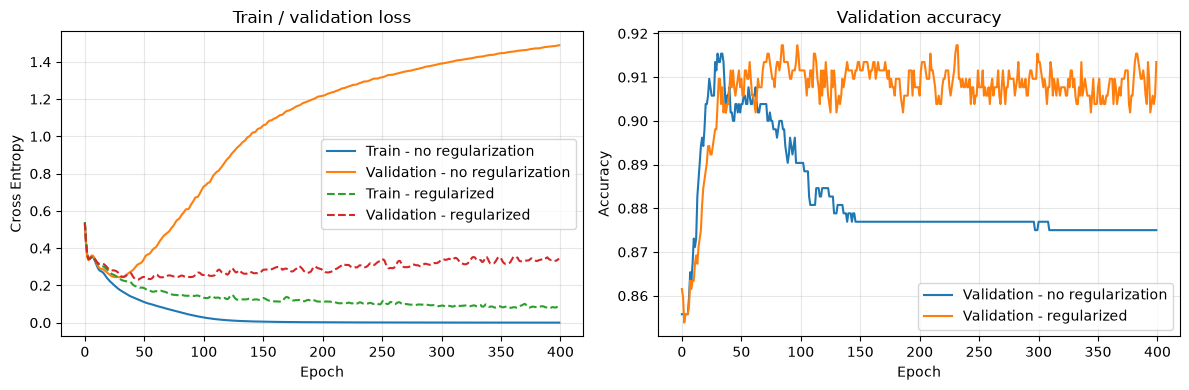

기준 모델 최종 검증 정확도: 0.8750
규제 모델 최종 검증 정확도: 0.9135


In [10]:
baseline_history = train_classifier(baseline_model, weight_decay=0.0)


regularized_history = train_classifier(regularized_model, weight_decay=1e-3)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].plot(baseline_history["train_loss"], label="Train - no regularization")
axes[0].plot(baseline_history["val_loss"], label="Validation - no regularization")
axes[0].plot(regularized_history["train_loss"], "--", label="Train - regularized")
axes[0].plot(regularized_history["val_loss"], "--", label="Validation - regularized")
axes[0].set_title("Train / validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross Entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(baseline_history["val_acc"], label="Validation - no regularization")
axes[1].plot(regularized_history["val_acc"], label="Validation - regularized")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(f"기준 모델 최종 검증 정확도: {baseline_history['val_acc'][-1]:.4f}")
print(f"규제 모델 최종 검증 정확도: {regularized_history['val_acc'][-1]:.4f}")


## 5. Scheduler, Early Stopping, L2 규제

| 방법 | 판단 기준 | 수행하는 일 | 핵심 인자 |
| --- | --- | --- | --- |
| StepLR | 정해진 epoch | 일정 주기마다 학습률 감소 | `step_size`, `gamma` |
| ReduceLROnPlateau | 검증 지표 정체 | 개선이 없으면 학습률 감소 | `factor`, `patience` |
| Early Stopping | 검증 지표 정체 | 학습 반복 중단 | `patience`, `min_delta` |
| Weight decay | 파라미터 크기 | 큰 가중치 억제 | `weight_decay` |

L2 규제는 손실에 가중치 제곱합을 추가하는 형태로 이해할 수 있다.

$$
L_{total}=L_{data}+\lambda\sum_i w_i^2
$$

Early Stopping은 단순히 반복을 멈추는 것만으로 끝나지 않는다. **검증 성능이 가장 좋았던 시점의 `state_dict`를 저장하고 마지막에 복원해야 한다.**

### 학습률 스케줄러 동작 비교

고정 주기로 감소하는 `StepLR`과 검증 손실 정체에 반응하는 `ReduceLROnPlateau`를 비교한다.

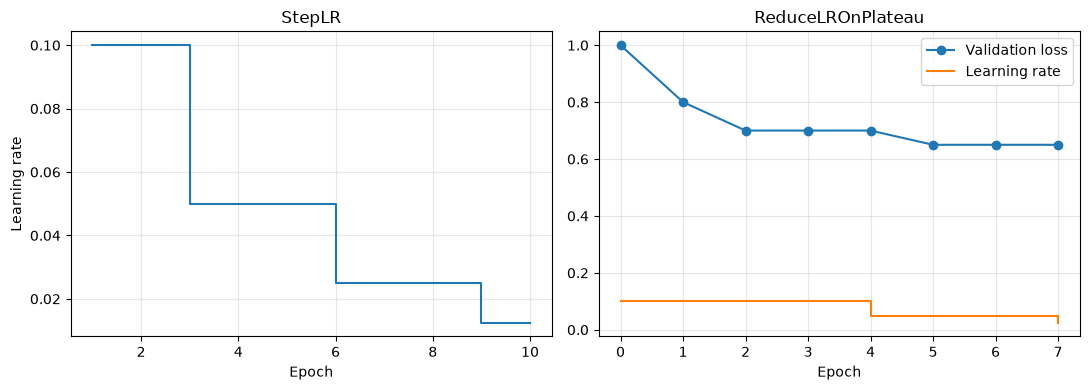

StepLR learning rates: [0.1, 0.1, 0.05, 0.05, 0.05, 0.025, 0.025, 0.025, 0.0125, 0.0125]
Plateau learning rates: [0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.025]


In [11]:
step_parameter = nn.Parameter(torch.tensor(1.0))


step_optimizer = optim.SGD([step_parameter], lr=0.1)


step_scheduler = optim.lr_scheduler.StepLR(step_optimizer, step_size=3, gamma=0.5)
step_lrs = []

for _ in range(10):

    step_optimizer.step()
    step_scheduler.step()


    step_lrs.append(step_optimizer.param_groups[0]["lr"])


plateau_parameter = nn.Parameter(torch.tensor(1.0))
plateau_optimizer = optim.SGD([plateau_parameter], lr=0.1)


plateau_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    plateau_optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

validation_losses = [1.0, 0.8, 0.7, 0.7, 0.7, 0.65, 0.65, 0.65]
plateau_lrs = []

for validation_loss in validation_losses:
    plateau_optimizer.step()


    plateau_scheduler.step(validation_loss)
    plateau_lrs.append(plateau_optimizer.param_groups[0]["lr"])


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].step(range(1, len(step_lrs) + 1), step_lrs, where="post")
axes[0].set_title("StepLR")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Learning rate")
axes[0].grid(alpha=0.3)

axes[1].plot(validation_losses, marker="o", label="Validation loss")
axes[1].step(range(len(plateau_lrs)), plateau_lrs, where="post", label="Learning rate")
axes[1].set_title("ReduceLROnPlateau")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("StepLR learning rates:", step_lrs)
print("Plateau learning rates:", plateau_lrs)


# StepLR은 step 3 간격으로, ReduceLROnPlateau는 검증 손실 정체 후
# learning rate를 줄인다

## 핵심 정리

- 일반화 성능은 학습 데이터가 아니라 검증·테스트 데이터로 판단한다.
- BatchNorm과 LayerNorm은 정규화 기준 축이 다르다.
- Dropout의 `p`는 제거 확률이며 학습 모드에서만 활성화된다.
- `model.eval()`과 `torch.no_grad()`는 서로 역할이 다르므로 평가 시 함께 사용한다.
- weight decay와 Dropout이 강할수록 항상 좋은 것은 아니며 검증 지표로 조정해야 한다.
- Early Stopping은 가장 좋은 모델 가중치를 저장·복원해야 한다.

### 확인 문제

1. Normalization과 Regularization의 목적은 어떻게 다른가?
2. BatchNorm과 LayerNorm은 어느 축을 기준으로 통계를 계산하는가?
3. Dropout의 학습·평가 모드 출력은 왜 다른가?
4. train loss는 감소하지만 validation loss가 증가한다면 어떤 상태인가?

## 아주 간단한 핵심 요약

이 노트북의 핵심은 **모델이 학습 데이터를 그대로 외우지 않고, 처음 보는 데이터도 잘 맞히게 만드는 방법**을 알아보는 것이다.

- **과적합**: 학습 데이터는 잘 맞히지만 새로운 데이터는 잘 맞히지 못하는 상태이다.
- **BatchNorm·LayerNorm**: 중간값의 분포를 정리해 학습이 안정적으로 진행되도록 돕는다. 두 방법은 평균과 분산을 계산하는 기준이 다르다.
- **Dropout**: 학습할 때 일부 출력을 무작위로 0으로 만들어 특정 뉴런에만 의존하지 않게 한다. 평가할 때는 사용하지 않는다.
- **Weight decay**: 가중치가 지나치게 커지지 않도록 제한해 모델이 너무 복잡해지는 것을 줄인다.
- **Scheduler**: 학습이 잘 진행되지 않을 때 학습률을 줄여 더 세밀하게 학습하도록 한다.
- **Early Stopping**: 검증 성능이 더 좋아지지 않으면 학습을 멈추고 가장 좋았던 모델을 사용한다.

### 코드에서 확인할 흐름

1. `model.train()`으로 학습 모드로 전환한다. Dropout이 활성화된다.
2. 순전파 → 손실 계산 → `backward()` → `optimizer.step()` 순서로 가중치를 학습한다.
3. `model.eval()`과 `torch.no_grad()`로 평가한다. Dropout과 기울기 계산이 비활성화된다.
4. train 성능과 validation 성능의 차이를 확인해 과적합 여부를 판단한다.

결론적으로 Dropout이나 weight decay를 많이 적용한다고 항상 좋은 것은 아니다. **validation loss가 낮고 train·validation 성능 차이가 작은 설정**을 선택해야 한다.